In [1]:
import pandas as pd
import numpy as np
import openpyxl

In [2]:
master = pd.read_csv(r"..\workingdata\master_data_wide.csv")
cluster = pd.read_csv(r"..\workingdata\clusters_list.csv")

In [3]:
master = pd.merge(master, cluster[["Country Code", "cluster_6"]], on= "Country Code", how="right")

In [4]:
master.drop(columns="Unnamed: 0", inplace=True)
master

,Country Code,Country Name,Year,Access to electricity (% of population),Accountability index,Adjusted savings: gross savings (% of GNI),Adjusted savings: natural resources depletion (% of GNI),Adjusted savings: total (current US$),Agriculture,Capital depreciation rate,...,Trade (% of GDP),Urban population (% of total population),"Use of IMF credit (DOD, current US$)",Welfare-relevant TFP,deliberative_dem,egalitarian_dem,electoral_dem,liberal_dem,participatory_dem,cluster_6
0,AFG,Afghanistan,1995.0,NaN,-1.118,NaN,NaN,NaN,NaN,NaN,...,NaN,3043587.0,NaN,NaN,0.027,0.041,0.094,0.022,0.025,0
1,AFG,Afghanistan,1996.0,NaN,-1.582,NaN,NaN,NaN,NaN,NaN,...,NaN,3190220.0,NaN,NaN,0.008,0.036,0.076,0.019,0.013,0
2,AFG,Afghanistan,1997.0,NaN,-1.697,NaN,NaN,NaN,NaN,NaN,...,NaN,3338510.0,NaN,NaN,0.007,0.040,0.073,0.022,0.013,0
3,AFG,Afghanistan,1998.0,NaN,-1.695,NaN,NaN,NaN,NaN,NaN,...,NaN,3493981.0,NaN,NaN,0.007,0.040,0.073,0.022,0.013,0
4,AFG,Afghanistan,1999.0,NaN,-1.689,NaN,NaN,NaN,NaN,NaN,...,NaN,3657429.0,NaN,NaN,0.007,0.040,0.073,0.022,0.013,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3371,ZWE,Zimbabwe,2015.0,33.7,0.048,-11.438012,4.581251,-4.648715e+09,8.284831,0.054977,...,56.749653,4832491.0,463752752.4,0.529631,0.225,0.185,0.296,0.208,0.236,0
3372,ZWE,Zimbabwe,2016.0,42.5,0.041,-5.670411,4.683162,-3.784872e+09,7.873585,0.056414,...,51.219038,4975772.0,455165191.5,0.510083,0.229,0.183,0.290,0.201,0.233,0
3373,ZWE,Zimbabwe,2017.0,44.0,0.116,-3.024929,5.905431,-3.049242e+09,7.247882,0.057745,...,55.028318,5140153.0,482184792.8,0.467629,0.236,0.178,0.295,0.221,0.238,0
3374,ZWE,Zimbabwe,2018.0,45.4,0.107,14.220834,2.783017,7.581995e+08,7.319201,0.059023,...,54.550317,5323482.0,470895600.2,0.337541,0.232,0.181,0.303,0.211,0.244,0


In [5]:
cmaster = master[(master["cluster_6"].isin([0,1,2,3,4])) & (master["Country Code"] !="HKG")]
cmaster

,Country Code,Country Name,Year,Access to electricity (% of population),Accountability index,Adjusted savings: gross savings (% of GNI),Adjusted savings: natural resources depletion (% of GNI),Adjusted savings: total (current US$),Agriculture,Capital depreciation rate,...,Trade (% of GDP),Urban population (% of total population),"Use of IMF credit (DOD, current US$)",Welfare-relevant TFP,deliberative_dem,egalitarian_dem,electoral_dem,liberal_dem,participatory_dem,cluster_6
0,AFG,Afghanistan,1995.0,NaN,-1.118,NaN,NaN,NaN,NaN,NaN,...,NaN,3043587.0,NaN,NaN,0.027,0.041,0.094,0.022,0.025,0
1,AFG,Afghanistan,1996.0,NaN,-1.582,NaN,NaN,NaN,NaN,NaN,...,NaN,3190220.0,NaN,NaN,0.008,0.036,0.076,0.019,0.013,0
2,AFG,Afghanistan,1997.0,NaN,-1.697,NaN,NaN,NaN,NaN,NaN,...,NaN,3338510.0,NaN,NaN,0.007,0.040,0.073,0.022,0.013,0
3,AFG,Afghanistan,1998.0,NaN,-1.695,NaN,NaN,NaN,NaN,NaN,...,NaN,3493981.0,NaN,NaN,0.007,0.040,0.073,0.022,0.013,0
4,AFG,Afghanistan,1999.0,NaN,-1.689,NaN,NaN,NaN,NaN,NaN,...,NaN,3657429.0,NaN,NaN,0.007,0.040,0.073,0.022,0.013,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3371,ZWE,Zimbabwe,2015.0,33.7,0.048,-11.438012,4.581251,-4.648715e+09,8.284831,0.054977,...,56.749653,4832491.0,463752752.4,0.529631,0.225,0.185,0.296,0.208,0.236,0
3372,ZWE,Zimbabwe,2016.0,42.5,0.041,-5.670411,4.683162,-3.784872e+09,7.873585,0.056414,...,51.219038,4975772.0,455165191.5,0.510083,0.229,0.183,0.290,0.201,0.233,0
3373,ZWE,Zimbabwe,2017.0,44.0,0.116,-3.024929,5.905431,-3.049242e+09,7.247882,0.057745,...,55.028318,5140153.0,482184792.8,0.467629,0.236,0.178,0.295,0.221,0.238,0
3374,ZWE,Zimbabwe,2018.0,45.4,0.107,14.220834,2.783017,7.581995e+08,7.319201,0.059023,...,54.550317,5323482.0,470895600.2,0.337541,0.232,0.181,0.303,0.211,0.244,0


In [6]:
print((cmaster['Country Code']).unique())
print((cmaster['Year']).unique())
print(cmaster.columns)

['AFG' 'DZA' 'ARG' 'ARM' 'AUS' 'AZE' 'BHR' 'BGD' 'BEN' 'BOL' 'BWA' 'BRA'
 'BFA' 'KHM' 'CMR' 'TCD' 'CHL' 'COL' 'COG' 'COD' 'CRI' 'CIV' 'DOM' 'ECU'
 'EGY' 'SLV' 'GNQ' 'SWZ' 'ETH' 'GAB' 'GEO' 'GHA' 'GTM' 'GIN' 'HTI' 'HND'
 'IND' 'IDN' 'IRN' 'IRQ' 'JAM' 'JOR' 'KAZ' 'KEN' 'KWT' 'KGZ' 'LAO' 'LBN'
 'LBY' 'MDG' 'MLI' 'MRT' 'MUS' 'MEX' 'MDA' 'MNG' 'MAR' 'MOZ' 'NAM' 'NPL'
 'NIC' 'NER' 'MKD' 'NOR' 'OMN' 'PAK' 'PAN' 'PNG' 'PRY' 'PER' 'PHL' 'QAT'
 'RUS' 'RWA' 'SAU' 'SEN' 'ZAF' 'LKA' 'SDN' 'TJK' 'TZA' 'THA' 'TGO' 'TUN'
 'TKM' 'UGA' 'ARE' 'URY' 'UZB' 'VEN' 'VNM' 'YEM' 'ZMB' 'ZWE']
[1995. 1996. 1997. 1998. 1999. 2000. 2001. 2002. 2003. 2004. 2005. 2006.
 2007. 2008. 2009. 2010. 2011. 2012. 2013. 2014. 2015. 2016. 2017. 2018.
 2019.]
Index(['Country Code', 'Country Name', 'Year',
       'Access to electricity (% of population)', 'Accountability index',
       'Adjusted savings: gross savings (% of GNI)',
       'Adjusted savings: natural resources depletion (% of GNI)',
       'Adjusted savings: total 

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# PART 1: VARIABLE-LEVEL MISSINGNESS ANALYSIS
# ============================================================

def analyze_variable_missingness(df):
    """Analyze missingness for each variable"""
    
    # Exclude identifier columns
    data_cols = [c for c in df.columns if c not in ['Country Code', 'Country Name', 'Year']]
    
    results = []
    for col in data_cols:
        valid_data = df[df[col].notna()]
        
        n_obs = valid_data.shape[0]
        n_missing = df[col].isna().sum()
        pct_missing = (n_missing / len(df)) * 100
        
        n_countries = valid_data['Country Code'].nunique()
        n_years = valid_data['Year'].dropna().nunique()
        
        year_range = f"{int(valid_data['Year'].min())}-{int(valid_data['Year'].max())}" if n_years > 0 else "N/A"
        
        results.append({
            'Variable': col,
            'Valid Obs': n_obs,
            'Missing': n_missing,
            '% Missing': round(pct_missing, 1),
            'Countries': n_countries,
            'Years': n_years,
            'Year Range': year_range
        })
    
    return pd.DataFrame(results).sort_values('% Missing', ascending=False)

# Run variable analysis
var_missing = analyze_variable_missingness(cmaster)
print("=" * 80)
print("VARIABLE-LEVEL MISSINGNESS SUMMARY")
print("=" * 80)
print(f"\nTotal observations: {len(cmaster)}")
print(f"Total countries: {cmaster['Country Code'].nunique()}")
print(f"Total years: {cmaster['Year'].dropna().nunique()}")
print("\n")
print(var_missing.to_string(index=False))

# ============================================================
# PART 2: COUNTRY-LEVEL MISSINGNESS ANALYSIS
# ============================================================

def analyze_country_missingness(df):
    """Analyze missingness by country"""
    
    data_cols = [c for c in df.columns if c not in ['Country Code', 'Country Name', 'Year']]
    
    results = []
    for code in df['Country Code'].unique():
        country_data = df[df['Country Code'] == code]
        country_name = country_data['Country Name'].iloc[0]
        
        n_rows = len(country_data)
        total_cells = n_rows * len(data_cols)
        missing_cells = country_data[data_cols].isna().sum().sum()
        pct_missing = (missing_cells / total_cells) * 100
        
        # Count variables with complete data for this country
        complete_vars = sum(country_data[col].notna().all() for col in data_cols)
        
        # Count variables with any data
        vars_with_data = sum(country_data[col].notna().any() for col in data_cols)
        
        # Year coverage
        years_covered = country_data['Year'].dropna().nunique()
        
        results.append({
            'Code': code,
            'Country': country_name,
            'Rows': n_rows,
            'Years Covered': years_covered,
            '% Missing': round(pct_missing, 1),
            'Complete Vars': complete_vars,
            'Vars with Data': vars_with_data,
            'Total Vars': len(data_cols)
        })
    
    return pd.DataFrame(results).sort_values('% Missing', ascending=False)

# Run country analysis
country_missing = analyze_country_missingness(cmaster)
print("\n\n")
print("=" * 80)
print("COUNTRY-LEVEL MISSINGNESS SUMMARY")
print("=" * 80)
print("\nTop 20 countries with MOST missing data:")
print(country_missing.head(20).to_string(index=False))
print("\n\nTop 20 countries with LEAST missing data:")
print(country_missing.tail(20).to_string(index=False))

# ============================================================
# PART 3: SUMMARY STATISTICS
# ============================================================

print("\n\n")
print("=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)

# Variables summary
print("\n--- Variable Coverage ---")
print(f"Variables with <10% missing: {(var_missing['% Missing'] < 10).sum()}")
print(f"Variables with 10-30% missing: {((var_missing['% Missing'] >= 10) & (var_missing['% Missing'] < 30)).sum()}")
print(f"Variables with 30-50% missing: {((var_missing['% Missing'] >= 30) & (var_missing['% Missing'] < 50)).sum()}")
print(f"Variables with >50% missing: {(var_missing['% Missing'] >= 50).sum()}")

# Countries summary
print("\n--- Country Coverage ---")
print(f"Countries with <20% missing: {(country_missing['% Missing'] < 20).sum()}")
print(f"Countries with 20-40% missing: {((country_missing['% Missing'] >= 20) & (country_missing['% Missing'] < 40)).sum()}")
print(f"Countries with >40% missing: {(country_missing['% Missing'] >= 40).sum()}")

# Most problematic variables (>50% missing)
print("\n--- Most Problematic Variables (>40% missing) ---")
problem_vars = var_missing[var_missing['% Missing'] > 40]['Variable'].tolist()
for v in problem_vars:
    print(f"  - {v}")

VARIABLE-LEVEL MISSINGNESS SUMMARY

Total observations: 2350
Total countries: 94
Total years: 25


                                                           Variable  Valid Obs  Missing  % Missing  Countries  Years Year Range
                                                  Production_Others         18     2332       99.2          3      6  2014-2019
                                                  Production_Metals        525     1825       77.7         27     25  1995-2019
                              General government structural balance        656     1694       72.1         31     25  1995-2019
                                        General government net debt        805     1545       65.7         38     25  1995-2019
                                                  High-tech exports        910     1440       61.3         88     13  2007-2019
                                             Reserves_Hydrocarbures       1000     1350       57.4         40     25  1995-2019
     

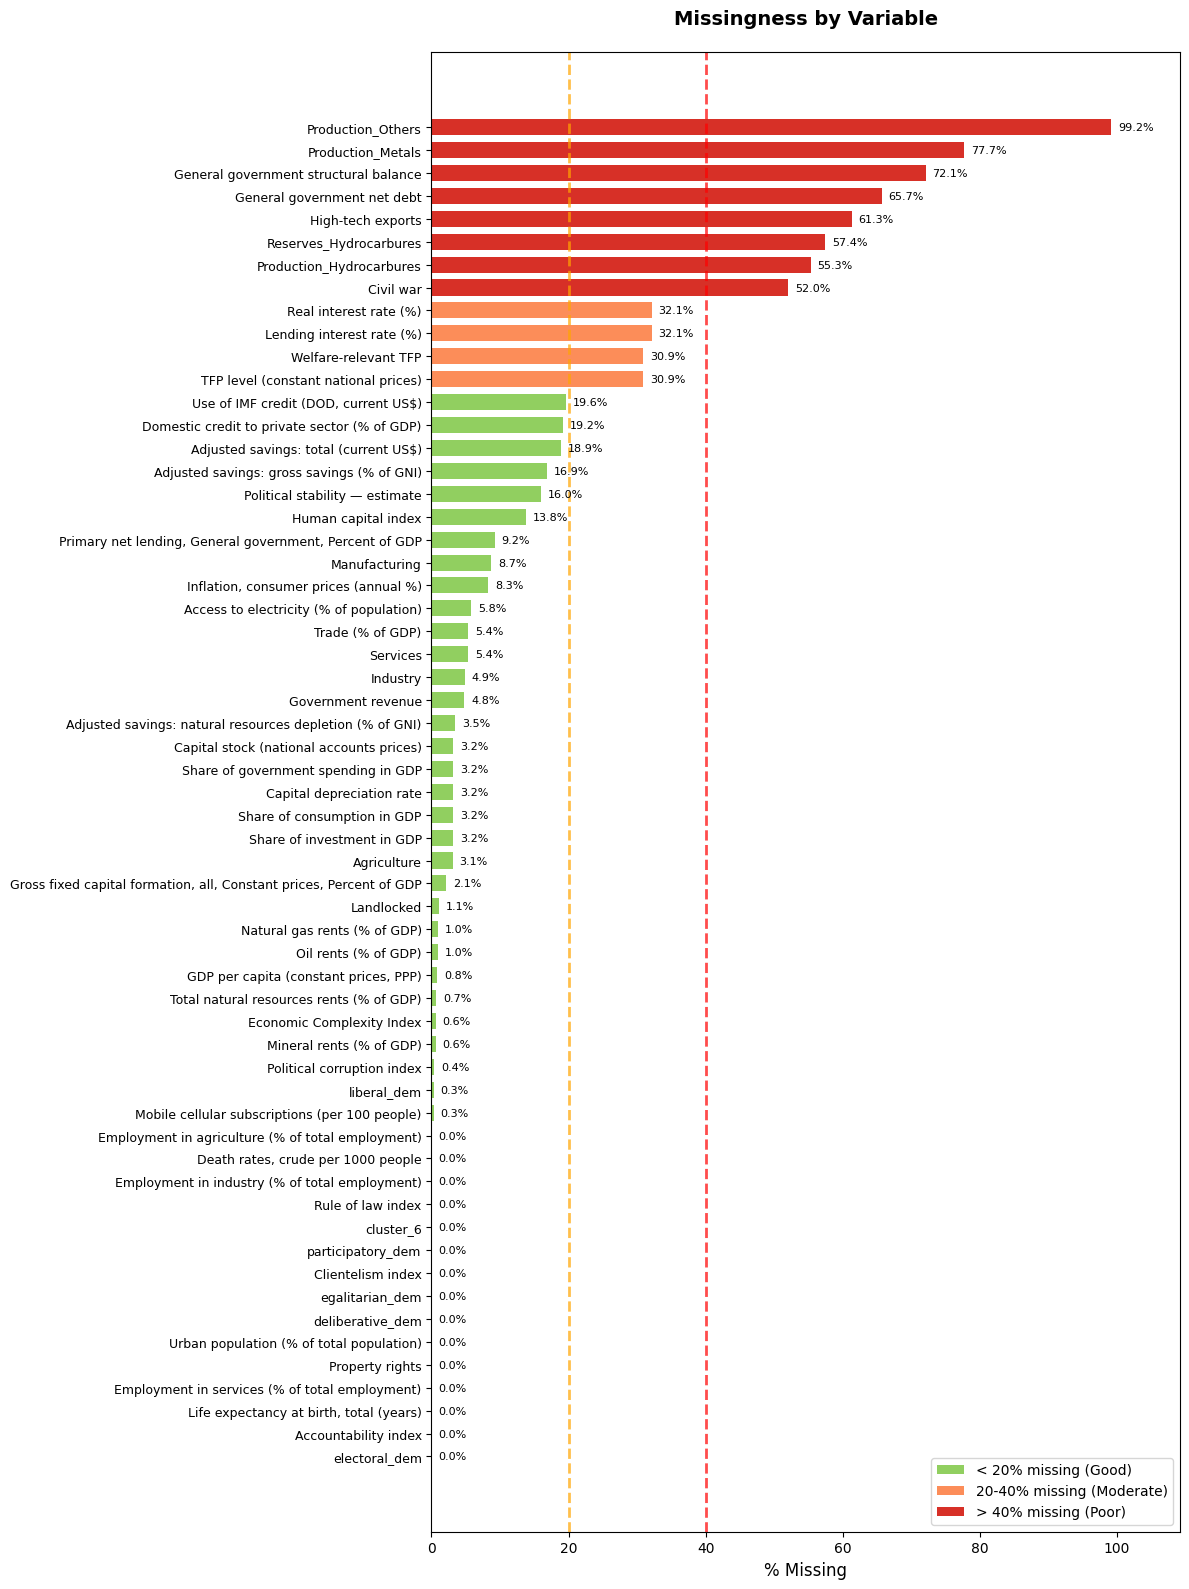

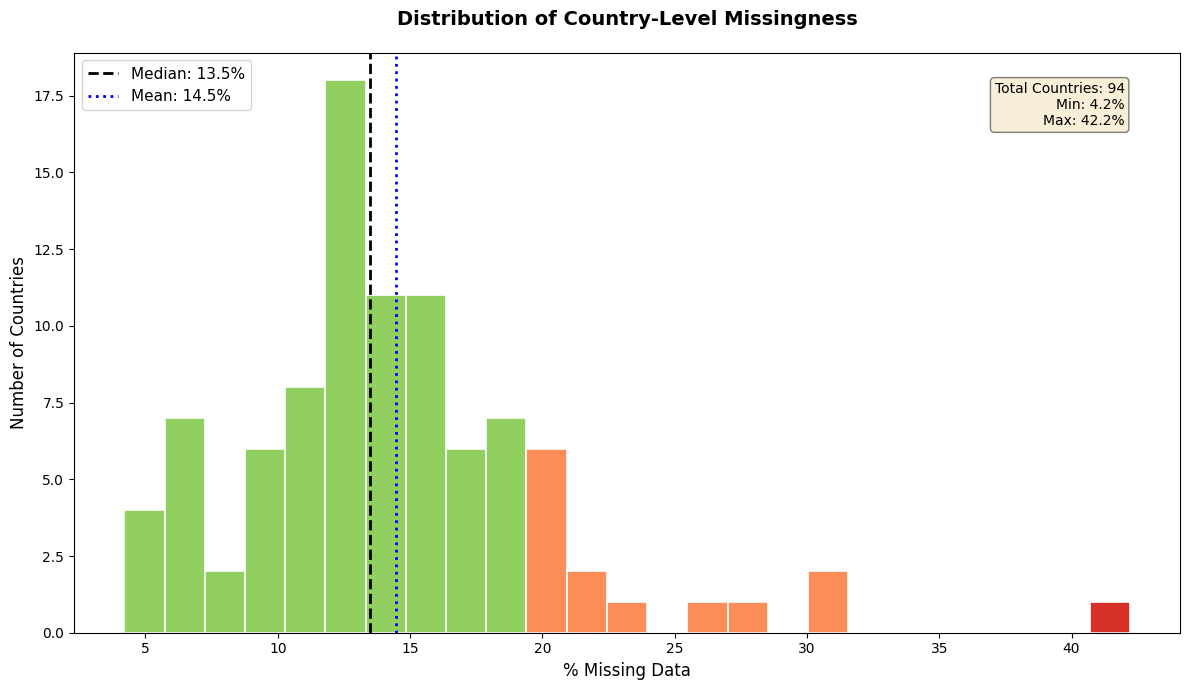

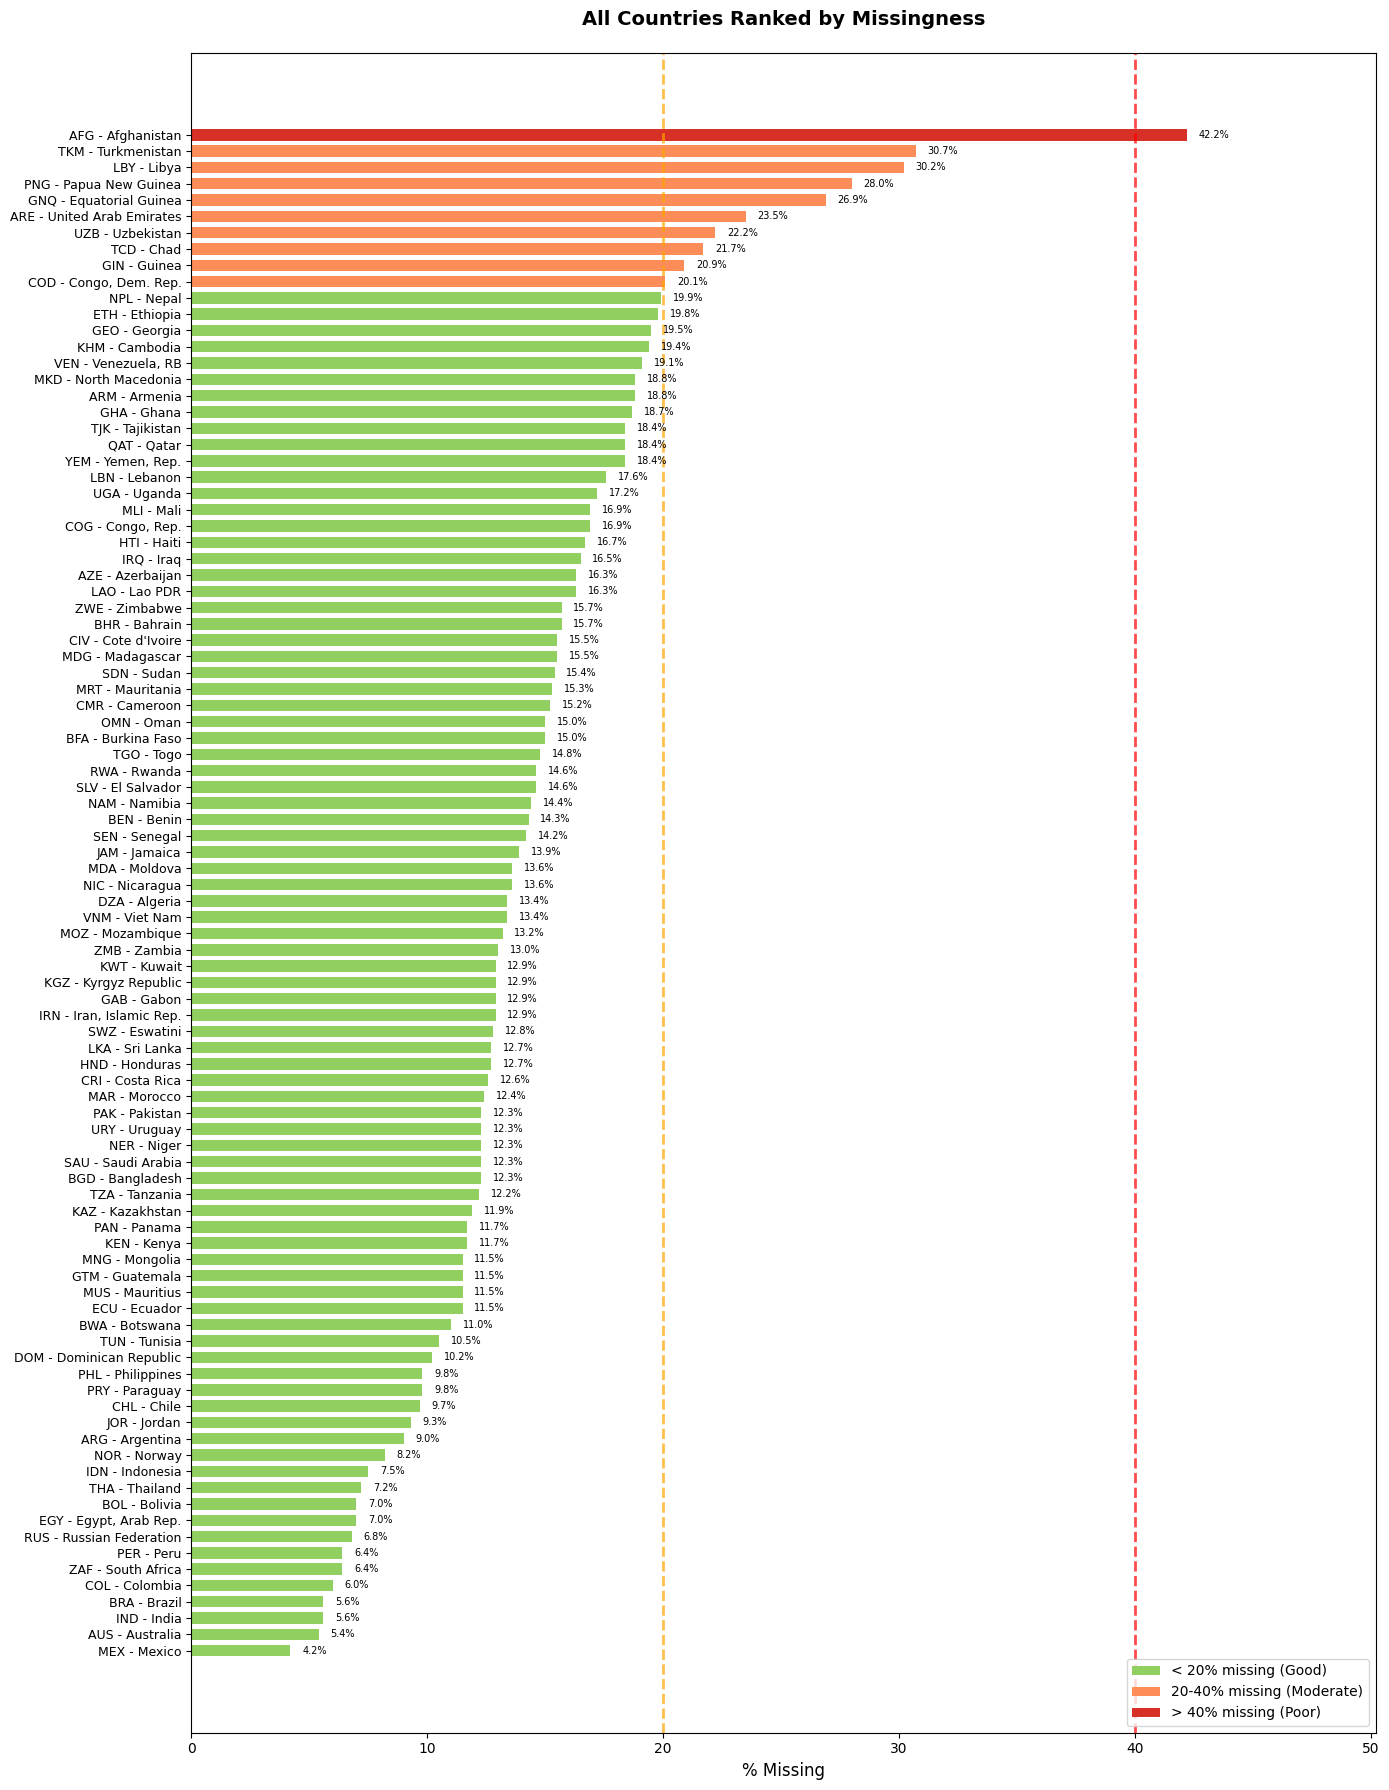

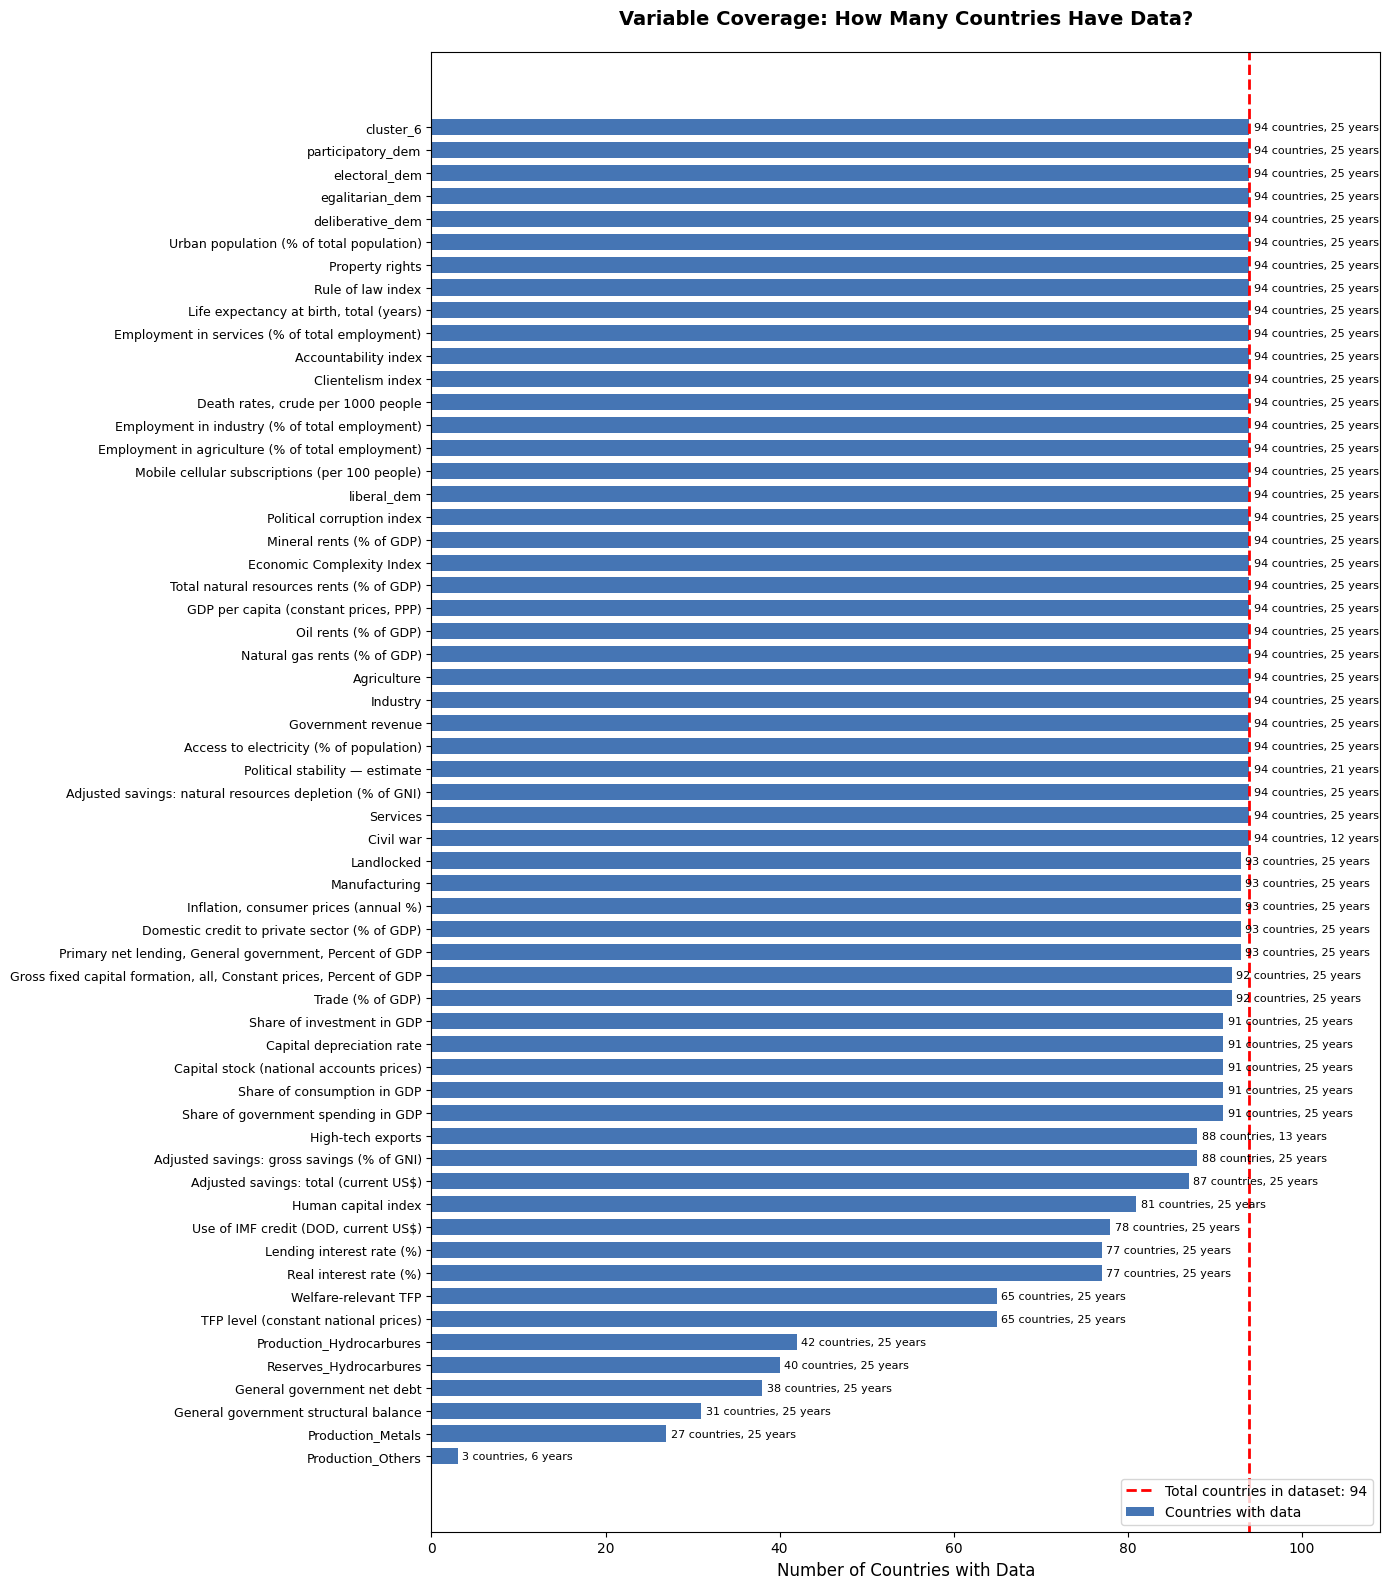

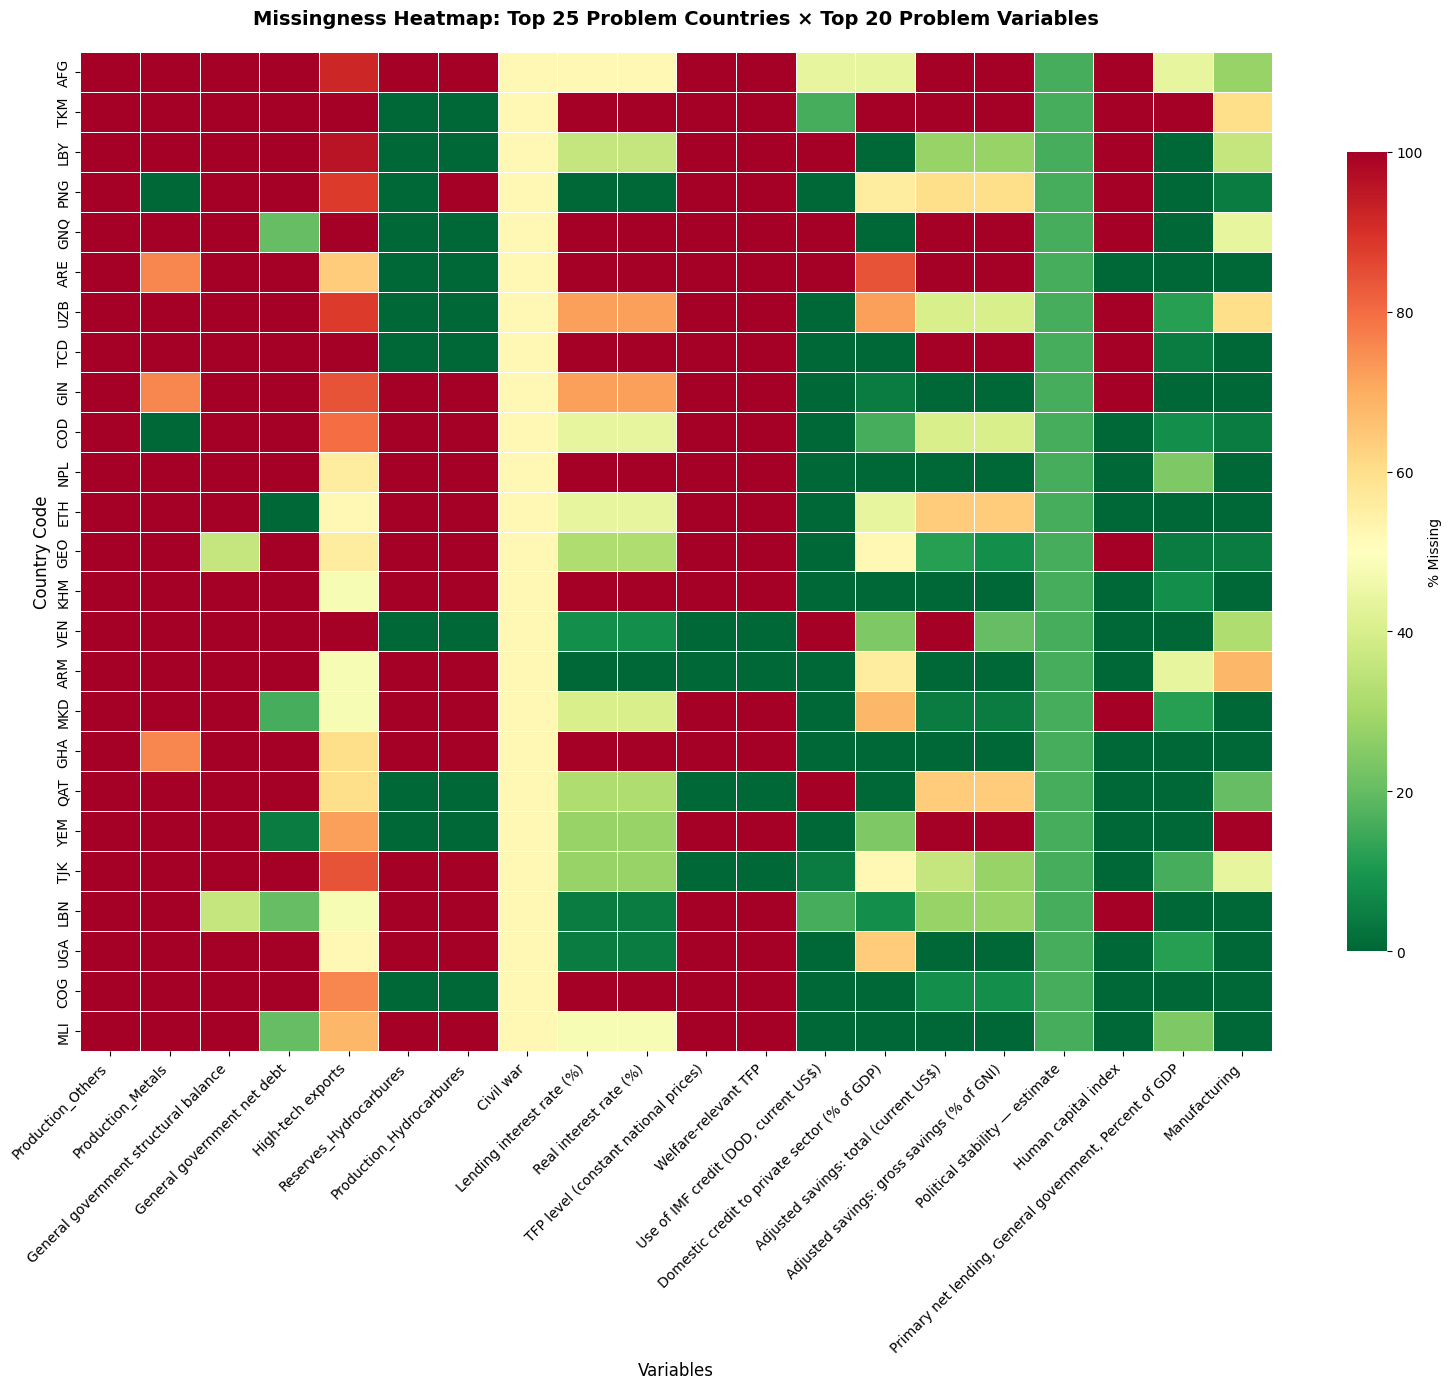

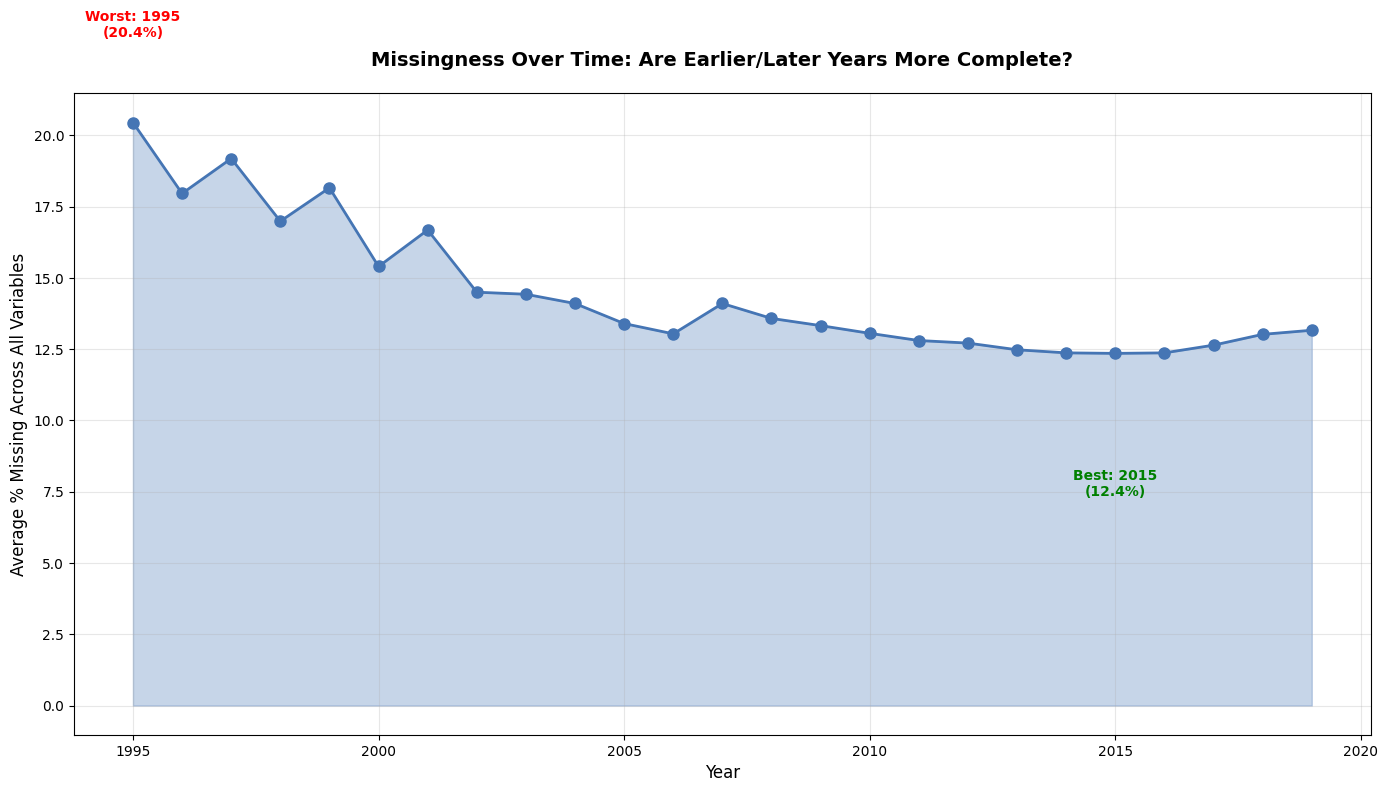


All plots saved as separate PNG files:
  - plot1_variable_missingness.png
  - plot2_country_distribution.png
  - plot3_all_countries_ranked.png
  - plot4_variable_coverage.png
  - plot5_heatmap_problem_areas.png
  - plot6_missingness_over_time.png


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ============================================================
# PLOT 1: Variable Missingness (Full Detail)
# ============================================================
fig1, ax1 = plt.subplots(figsize=(12, 16))

var_sorted = var_missing.sort_values('% Missing', ascending=True)
colors = ['#d73027' if x > 40 else '#fc8d59' if x > 20 else '#91cf60' for x in var_sorted['% Missing']]

bars = ax1.barh(range(len(var_sorted)), var_sorted['% Missing'], color=colors, height=0.7)
ax1.set_xlabel('% Missing', fontsize=12)
ax1.set_title('Missingness by Variable', fontsize=14, fontweight='bold', pad=20)
ax1.set_yticks(range(len(var_sorted)))
ax1.set_yticklabels(var_sorted['Variable'], fontsize=9)
ax1.axvline(x=20, color='orange', linestyle='--', alpha=0.7, linewidth=2)
ax1.axvline(x=40, color='red', linestyle='--', alpha=0.7, linewidth=2)

# Add value labels on bars
for i, (val, var) in enumerate(zip(var_sorted['% Missing'], var_sorted['Variable'])):
    ax1.text(val + 1, i, f'{val:.1f}%', va='center', fontsize=8)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#91cf60', label='< 20% missing (Good)'),
    Patch(facecolor='#fc8d59', label='20-40% missing (Moderate)'),
    Patch(facecolor='#d73027', label='> 40% missing (Poor)')
]
ax1.legend(handles=legend_elements, loc='lower right', fontsize=10)
ax1.set_xlim(0, max(var_sorted['% Missing']) + 10)

plt.tight_layout()
plt.savefig(f'..\\figures\\missing_check\\plot1_variable_missingness.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# PLOT 2: Country Missingness Distribution
# ============================================================
fig2, ax2 = plt.subplots(figsize=(12, 7))

n, bins, patches = ax2.hist(country_missing['% Missing'], bins=25, color='steelblue', 
                             edgecolor='white', linewidth=1.2)

# Color bins by severity
for i, patch in enumerate(patches):
    bin_center = (bins[i] + bins[i+1]) / 2
    if bin_center > 40:
        patch.set_facecolor('#d73027')
    elif bin_center > 20:
        patch.set_facecolor('#fc8d59')
    else:
        patch.set_facecolor('#91cf60')

ax2.axvline(country_missing['% Missing'].median(), color='black', linestyle='--', 
            linewidth=2, label=f"Median: {country_missing['% Missing'].median():.1f}%")
ax2.axvline(country_missing['% Missing'].mean(), color='blue', linestyle=':', 
            linewidth=2, label=f"Mean: {country_missing['% Missing'].mean():.1f}%")

ax2.set_xlabel('% Missing Data', fontsize=12)
ax2.set_ylabel('Number of Countries', fontsize=12)
ax2.set_title('Distribution of Country-Level Missingness', fontsize=14, fontweight='bold', pad=20)
ax2.legend(fontsize=11)

# Add summary text
textstr = f'Total Countries: {len(country_missing)}\nMin: {country_missing["% Missing"].min():.1f}%\nMax: {country_missing["% Missing"].max():.1f}%'
ax2.text(0.95, 0.95, textstr, transform=ax2.transAxes, fontsize=10,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(f'..\\figures\\missing_check\\plot2_country_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# PLOT 3: All Countries Ranked by Missingness
# ============================================================
fig3, ax3 = plt.subplots(figsize=(14, 18))

country_sorted = country_missing.sort_values('% Missing', ascending=True)
colors = ['#d73027' if x > 40 else '#fc8d59' if x > 20 else '#91cf60' for x in country_sorted['% Missing']]

ax3.barh(range(len(country_sorted)), country_sorted['% Missing'], color=colors, height=0.7)
ax3.set_yticks(range(len(country_sorted)))

labels = [f"{row['Code']} - {str(row['Country'])[:25] if pd.notna(row['Country']) else 'N/A'}" 
          for _, row in country_sorted.iterrows()]
ax3.set_yticklabels(labels, fontsize=9)

ax3.set_xlabel('% Missing', fontsize=12)
ax3.set_title('All Countries Ranked by Missingness', fontsize=14, fontweight='bold', pad=20)
ax3.axvline(x=20, color='orange', linestyle='--', alpha=0.7, linewidth=2)
ax3.axvline(x=40, color='red', linestyle='--', alpha=0.7, linewidth=2)

# Add value labels
for i, val in enumerate(country_sorted['% Missing']):
    ax3.text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=7)

ax3.legend(handles=legend_elements, loc='lower right', fontsize=10)
ax3.set_xlim(0, max(country_sorted['% Missing']) + 8)

plt.tight_layout()
plt.savefig(f'..\\figures\\missing_check\\plot3_all_countries_ranked.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# PLOT 4: Variable Coverage (Countries & Years)
# ============================================================
fig4, ax4 = plt.subplots(figsize=(14, 16))

var_sorted2 = var_missing.sort_values('Countries', ascending=True)

ax4.barh(range(len(var_sorted2)), var_sorted2['Countries'], color='#4575b4', 
         height=0.7, label='Countries with data')

ax4.set_yticks(range(len(var_sorted2)))
ax4.set_yticklabels(var_sorted2['Variable'], fontsize=9)
ax4.set_xlabel('Number of Countries with Data', fontsize=12)
ax4.set_title('Variable Coverage: How Many Countries Have Data?', fontsize=14, fontweight='bold', pad=20)

# Add total countries line
total_countries = cmaster['Country Code'].nunique()
ax4.axvline(x=total_countries, color='red', linestyle='--', linewidth=2, 
            label=f'Total countries in dataset: {total_countries}')

# Add value labels
for i, (countries, years) in enumerate(zip(var_sorted2['Countries'], var_sorted2['Years'])):
    ax4.text(countries + 0.5, i, f'{countries} countries, {years} years', va='center', fontsize=8)

ax4.legend(loc='lower right', fontsize=10)
ax4.set_xlim(0, total_countries + 15)

plt.tight_layout()
plt.savefig(f'..\\figures\\missing_check\\plot4_variable_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# PLOT 5: Heatmap - Countries vs Key Variables
# ============================================================
fig5, ax5 = plt.subplots(figsize=(16, 14))

data_cols = [c for c in cmaster.columns if c not in ['Country Code', 'Country Name', 'Year']]
missing_matrix = cmaster.groupby('Country Code')[data_cols].apply(lambda x: x.isna().mean() * 100)

# Select top 25 most problematic countries and top 20 variables
top_countries = country_missing.head(25)['Code'].tolist()
top_vars = var_missing.head(20)['Variable'].tolist()

heatmap_data = missing_matrix.loc[top_countries, top_vars]

sns.heatmap(heatmap_data, cmap='RdYlGn_r', ax=ax5, 
            cbar_kws={'label': '% Missing', 'shrink': 0.8},
            xticklabels=True, yticklabels=True,
            linewidths=0.5, linecolor='white',
            vmin=0, vmax=100)

ax5.set_xticklabels(ax5.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax5.set_yticklabels(ax5.get_yticklabels(), fontsize=10)
ax5.set_title('Missingness Heatmap: Top 25 Problem Countries × Top 20 Problem Variables', 
              fontsize=14, fontweight='bold', pad=20)
ax5.set_xlabel('Variables', fontsize=12)
ax5.set_ylabel('Country Code', fontsize=12)

plt.tight_layout()
plt.savefig(f'..\\figures\\missing_check\\plot5_heatmap_problem_areas.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# PLOT 6: Missingness Over Time
# ============================================================
fig6, ax6 = plt.subplots(figsize=(14, 8))

# Calculate missingness by year
yearly_missing = cmaster.groupby('Year')[data_cols].apply(lambda x: x.isna().mean() * 100).mean(axis=1)
yearly_missing = yearly_missing.dropna()

ax6.plot(yearly_missing.index, yearly_missing.values, marker='o', linewidth=2, 
         markersize=8, color='#4575b4')
ax6.fill_between(yearly_missing.index, yearly_missing.values, alpha=0.3, color='#4575b4')

ax6.set_xlabel('Year', fontsize=12)
ax6.set_ylabel('Average % Missing Across All Variables', fontsize=12)
ax6.set_title('Missingness Over Time: Are Earlier/Later Years More Complete?', 
              fontsize=14, fontweight='bold', pad=20)
ax6.grid(True, alpha=0.3)

# Add annotations for min/max
min_year = yearly_missing.idxmin()
max_year = yearly_missing.idxmax()
ax6.annotate(f'Best: {min_year:.0f}\n({yearly_missing[min_year]:.1f}%)', 
             xy=(min_year, yearly_missing[min_year]), fontsize=10,
             xytext=(min_year, yearly_missing[min_year] - 5),
             ha='center', color='green', fontweight='bold')
ax6.annotate(f'Worst: {max_year:.0f}\n({yearly_missing[max_year]:.1f}%)', 
             xy=(max_year, yearly_missing[max_year]), fontsize=10,
             xytext=(max_year, yearly_missing[max_year] + 3),
             ha='center', color='red', fontweight='bold')

plt.tight_layout()
plt.savefig(f'..\\figures\\missing_check\\plot6_missingness_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("All plots saved as separate PNG files:")
print("  - plot1_variable_missingness.png")
print("  - plot2_country_distribution.png")
print("  - plot3_all_countries_ranked.png")
print("  - plot4_variable_coverage.png")
print("  - plot5_heatmap_problem_areas.png")
print("  - plot6_missingness_over_time.png")
print("="*60)

In [9]:
import plotly.express as px
import plotly.graph_objects as go

# Create interactive scatter plot
fig = px.scatter(
    country_missing,
    x='Vars with Data',
    y='% Missing',
    color='% Missing',
    color_continuous_scale='RdYlGn_r',
    hover_name='Country',
    hover_data={
        'Code': True,
        'Vars with Data': True,
        '% Missing': ':.1f',
        'Complete Vars': True,
        'Years Covered': True,
        'Rows': True
    },
    title='Country Data Profile: Coverage vs Completeness<br><sup>Hover over points to see country details</sup>',
    labels={
        'Vars with Data': 'Number of Variables with Any Data',
        '% Missing': '% Missing Data Overall',
        'Complete Vars': 'Variables with Complete Data',
        'Years Covered': 'Years Covered'
    }
)

# Update marker styling
fig.update_traces(
    marker=dict(
        size=14,
        line=dict(width=1, color='black'),
        opacity=0.7
    )
)

# Update layout
fig.update_layout(
    width=1000,
    height=700,
    font=dict(size=12),
    title_font=dict(size=16),
    xaxis=dict(
        title_font=dict(size=14),
        gridcolor='lightgray',
        gridwidth=0.5
    ),
    yaxis=dict(
        title_font=dict(size=14),
        gridcolor='lightgray',
        gridwidth=0.5
    ),
    coloraxis_colorbar=dict(
        title='% Missing',
        ticksuffix='%'
    ),
    plot_bgcolor='white',
    hovermode='closest'
)

# Add quadrant lines for reference
median_vars = country_missing['Vars with Data'].median()
median_missing = country_missing['% Missing'].median()

fig.add_hline(y=median_missing, line_dash="dash", line_color="gray", opacity=0.5,
              annotation_text=f"Median: {median_missing:.1f}%", annotation_position="right")
fig.add_vline(x=median_vars, line_dash="dash", line_color="gray", opacity=0.5,
              annotation_text=f"Median: {median_vars:.0f} vars", annotation_position="top")

# Show the plot
fig.show()

# Save as interactive HTML file
fig.write_html('plot7_interactive_country_profile.html')
print("\nInteractive plot saved as 'plot7_interactive_country_profile.html'")
print("Open this file in a browser for full interactivity!")


Interactive plot saved as 'plot7_interactive_country_profile.html'
Open this file in a browser for full interactivity!


In [10]:
import pandas as pd
import numpy as np

# Define variables of interest
vars_of_interest = [
    'GDP per capita (constant prices, PPP)',
    'Total natural resources rents (% of GDP)',
    'Rule of law index',
    'Employment in industry (% of total employment)',
    'Economic Complexity Index'
]

# Get top 5 missing countries
top5_missing_codes = country_missing.head(5)['Code'].tolist()

# Split the data
top5_df = cmaster[cmaster['Country Code'].isin(top5_missing_codes)]
rest_df = cmaster[~cmaster['Country Code'].isin(top5_missing_codes)]

# Function to calculate descriptive statistics
def calc_desc_stats(df, varname):
    data = df[varname].dropna()
    if len(data) == 0:
        return pd.Series({
            'N': 0, 'Mean': np.nan, 'Std': np.nan, 
            'Min': np.nan, '25%': np.nan, 'Median': np.nan, 
            '75%': np.nan, 'Max': np.nan
        })
    return pd.Series({
        'N': len(data),
        'Mean': data.mean(),
        'Std': data.std(),
        'Min': data.min(),
        '25%': data.quantile(0.25),
        'Median': data.median(),
        '75%': data.quantile(0.75),
        'Max': data.max()
    })

# Build comparison table
results = []

for var in vars_of_interest:
    # Stats for top 5 missing
    top5_stats = calc_desc_stats(top5_df, var)
    top5_stats['Group'] = 'Top 5 Missing'
    top5_stats['Variable'] = var
    
    # Stats for rest
    rest_stats = calc_desc_stats(rest_df, var)
    rest_stats['Group'] = 'Rest of Countries'
    rest_stats['Variable'] = var
    
    results.append(top5_stats)
    results.append(rest_stats)

# Create dataframe
stats_df = pd.DataFrame(results)
stats_df = stats_df[['Variable', 'Group', 'N', 'Mean', 'Std', 'Min', '25%', 'Median', '75%', 'Max']]

# Round numeric columns
numeric_cols = ['Mean', 'Std', 'Min', '25%', 'Median', '75%', 'Max']
stats_df[numeric_cols] = stats_df[numeric_cols].round(2)
stats_df['N'] = stats_df['N'].astype(int)


# Create a cleaner side-by-side comparison table
print("\n")
print("=" * 100)
print("SIDE-BY-SIDE MEAN COMPARISON")
print("=" * 100)

comparison = []
for var in vars_of_interest:
    top5_mean = top5_df[var].mean()
    rest_mean = rest_df[var].mean()
    diff = top5_mean - rest_mean
    pct_diff = (diff / rest_mean * 100) if rest_mean != 0 else np.nan
    
    comparison.append({
        'Variable': var,
        'Top 5 Missing (Mean)': round(top5_mean, 2),
        'Rest of Countries (Mean)': round(rest_mean, 2),
        'Difference': round(diff, 2),
        '% Difference': round(pct_diff, 1)
    })

comparison_df = pd.DataFrame(comparison)
print(comparison_df.to_string(index=False))

# # Save to CSV
# stats_df.to_csv('descriptive_stats_by_missingness.csv', index=False)
# comparison_df.to_csv('mean_comparison_by_missingness.csv', index=False)
# print("\n\nTables saved as CSV files.")



SIDE-BY-SIDE MEAN COMPARISON
                                      Variable  Top 5 Missing (Mean)  Rest of Countries (Mean)  Difference  % Difference
         GDP per capita (constant prices, PPP)              14158.73                  12281.24     1877.49          15.3
      Total natural resources rents (% of GDP)                 29.11                      9.67       19.44         201.0
                             Rule of law index                  0.17                      0.44       -0.26         -60.3
Employment in industry (% of total employment)                 16.07                     18.69       -2.62         -14.0
                     Economic Complexity Index                 -1.19                     -0.47       -0.71         150.9


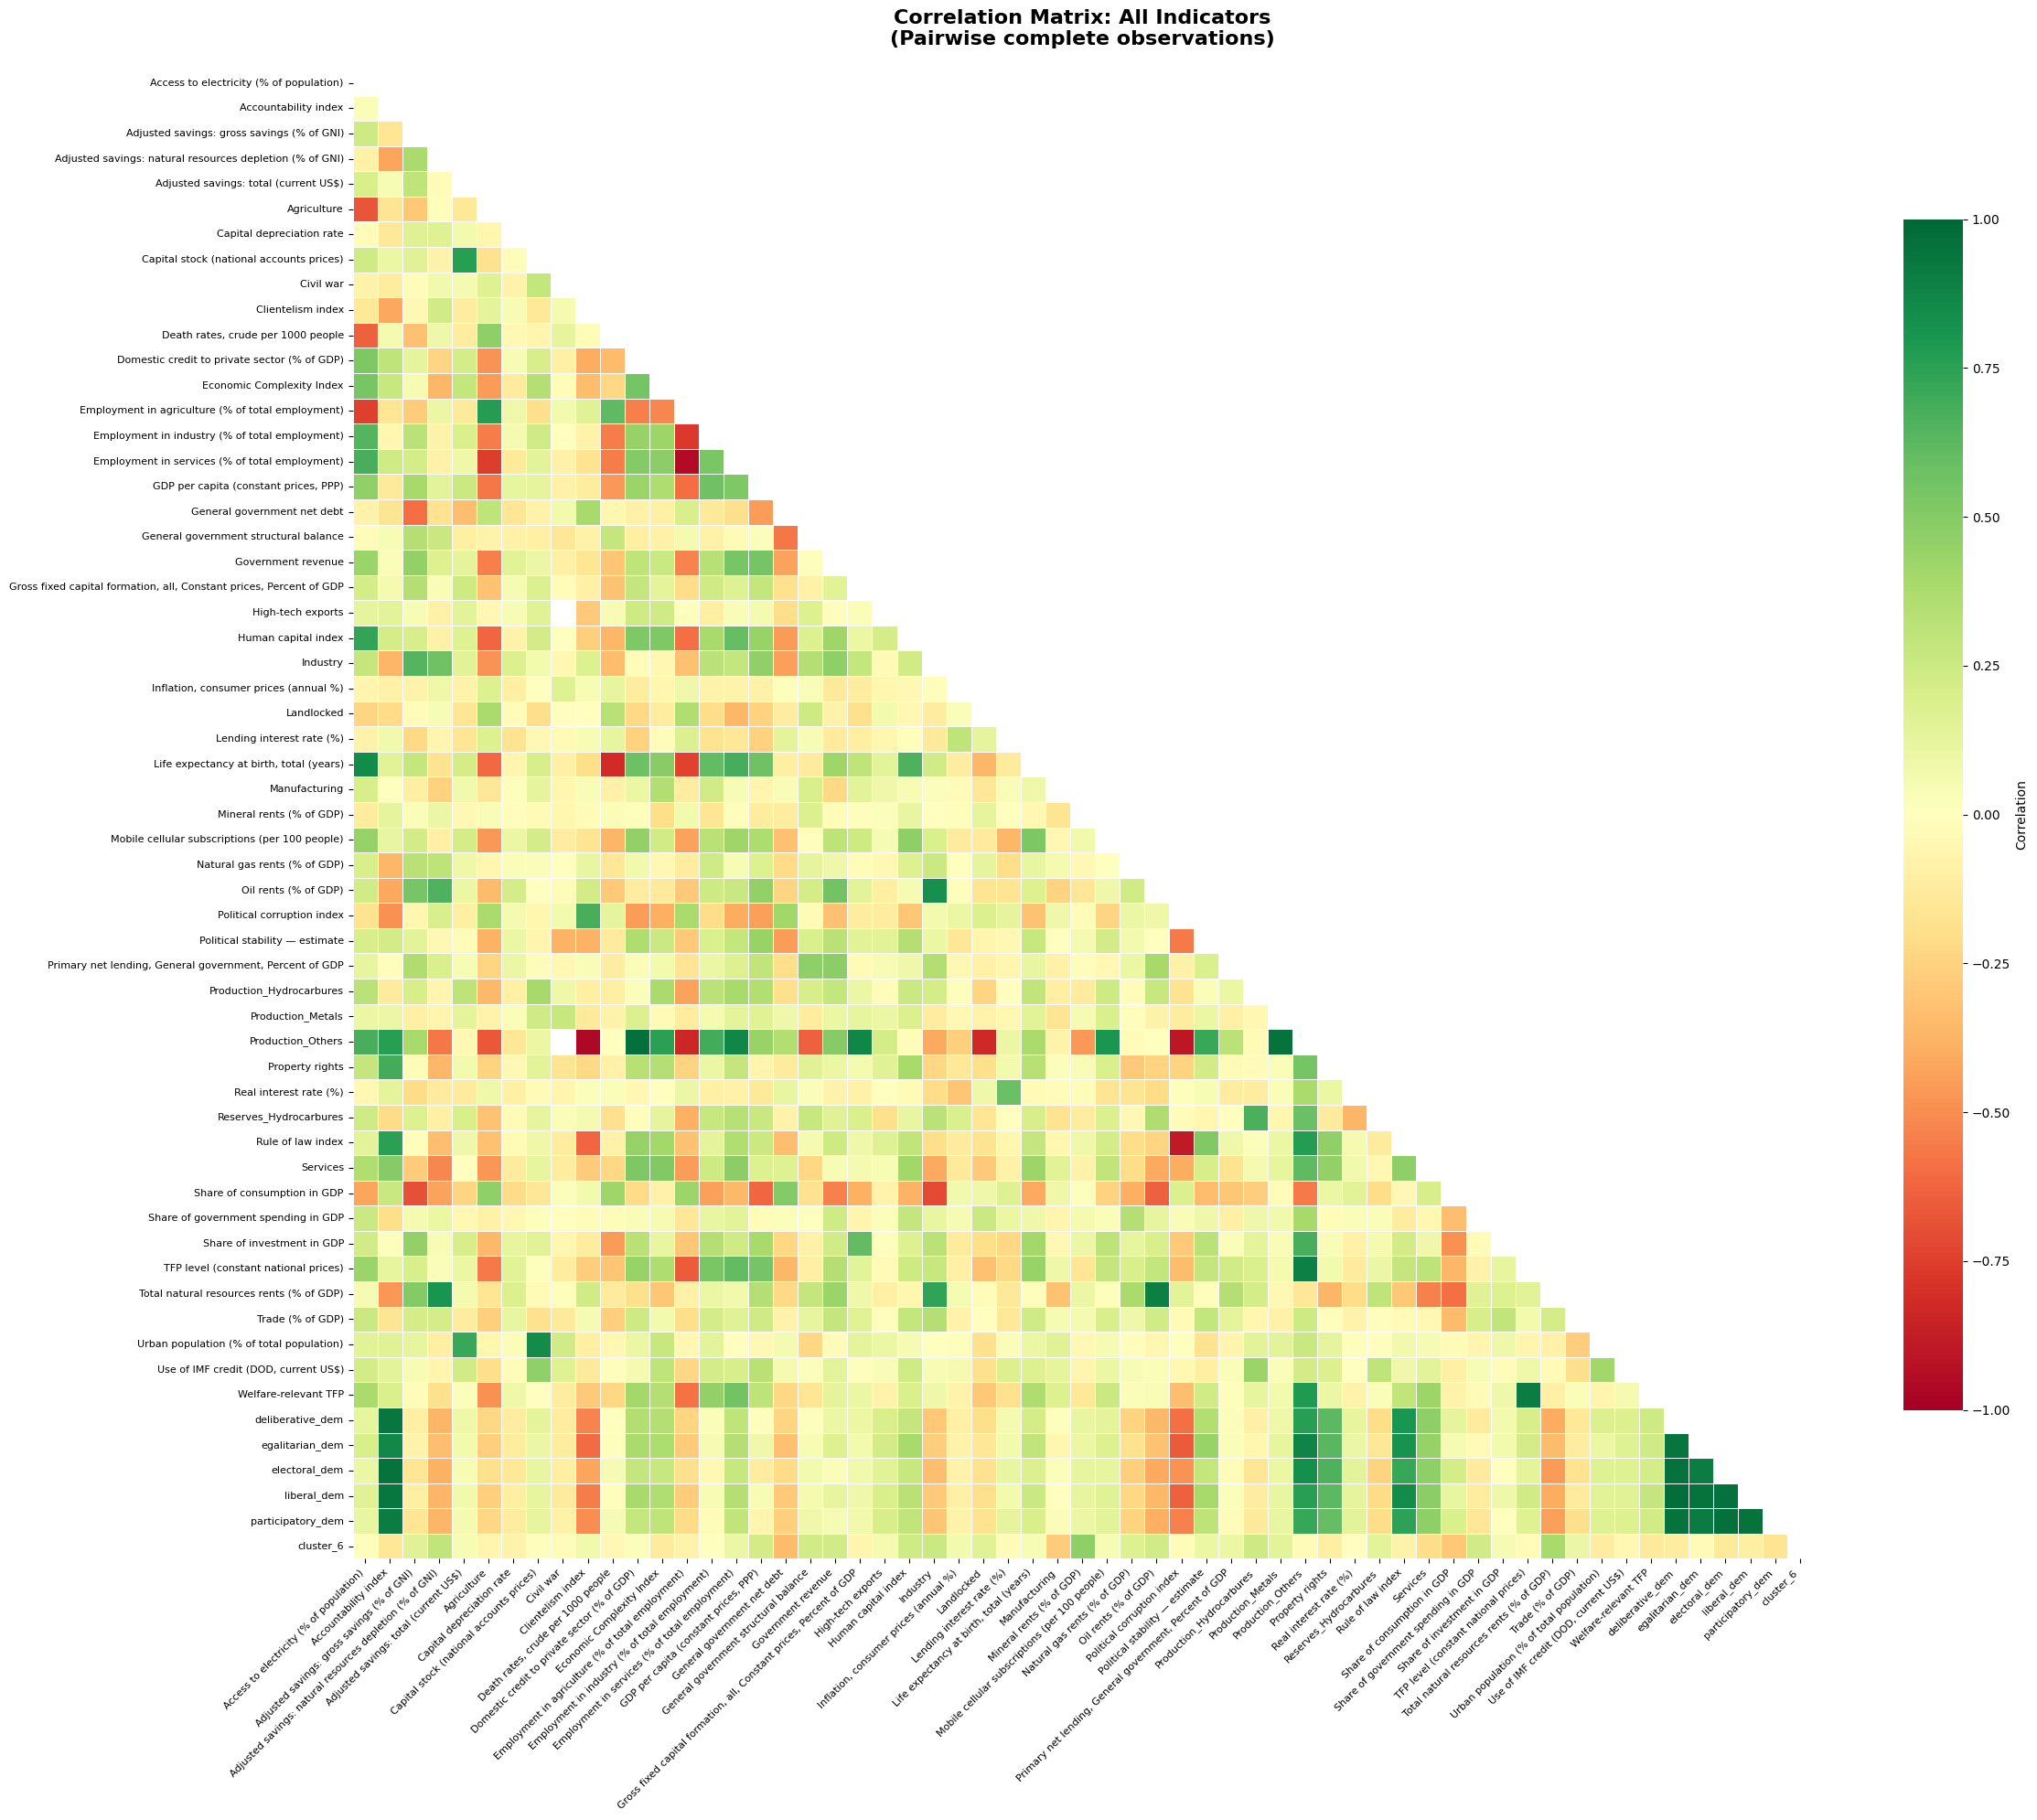

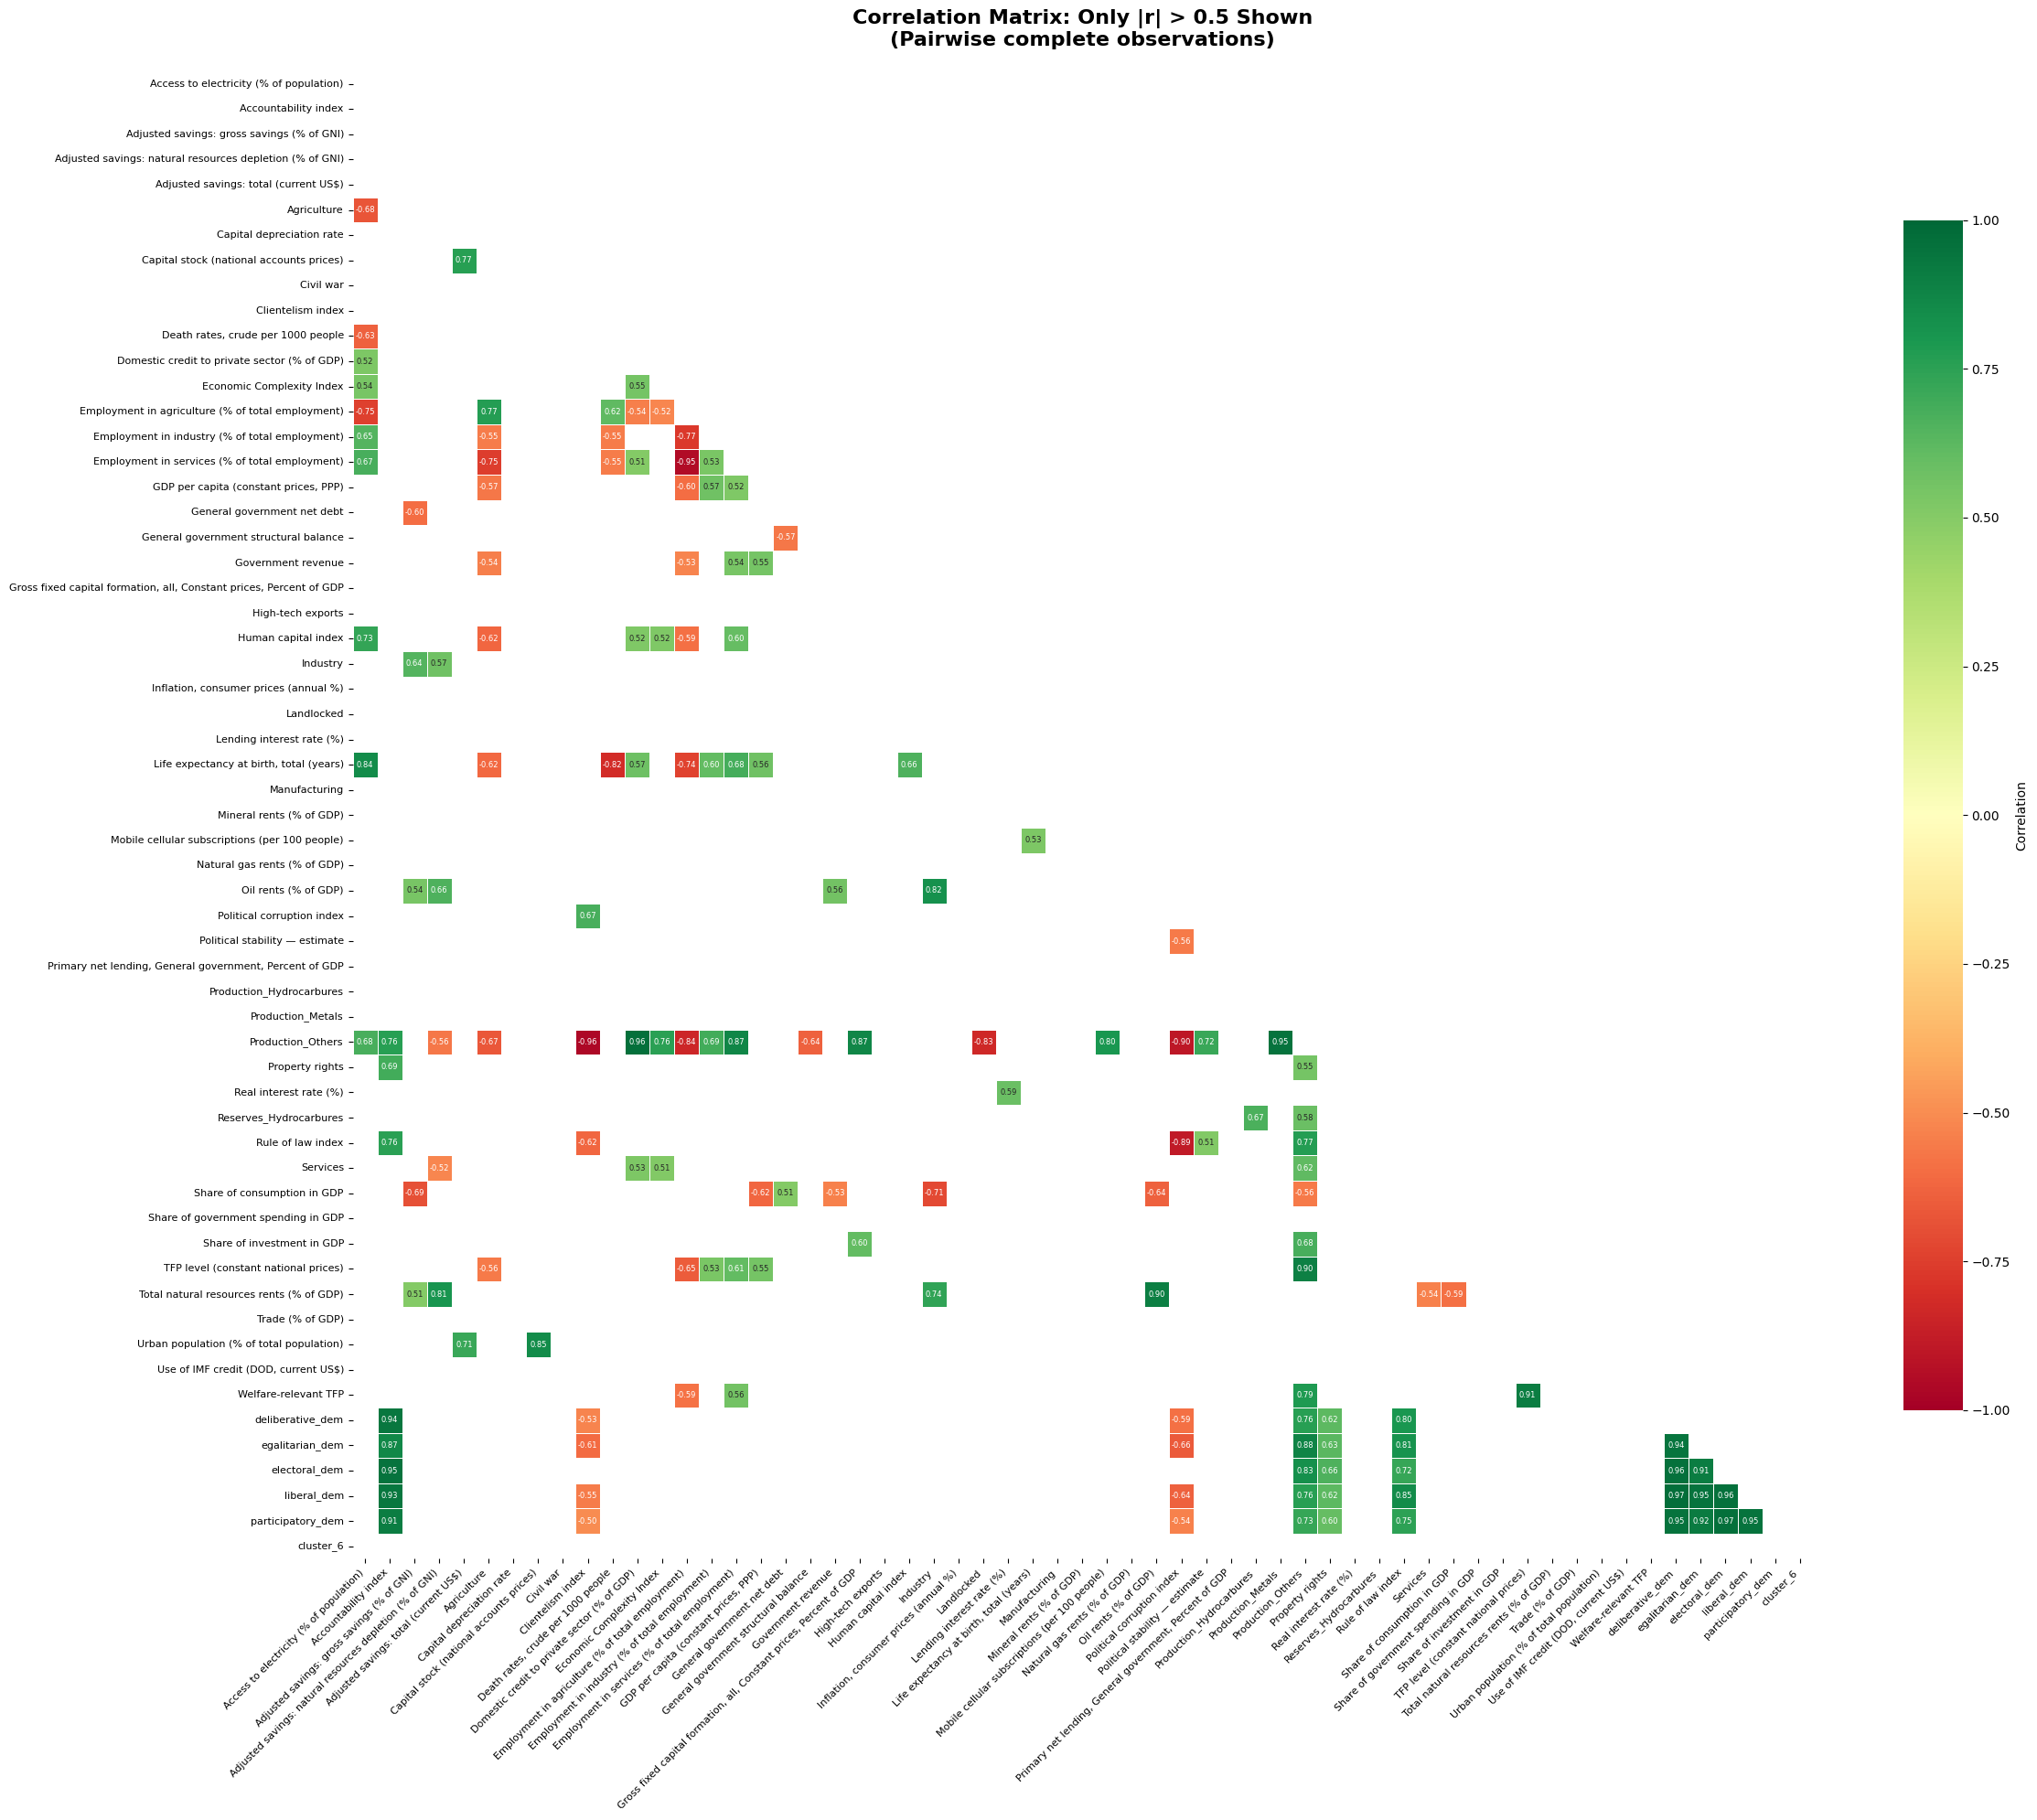

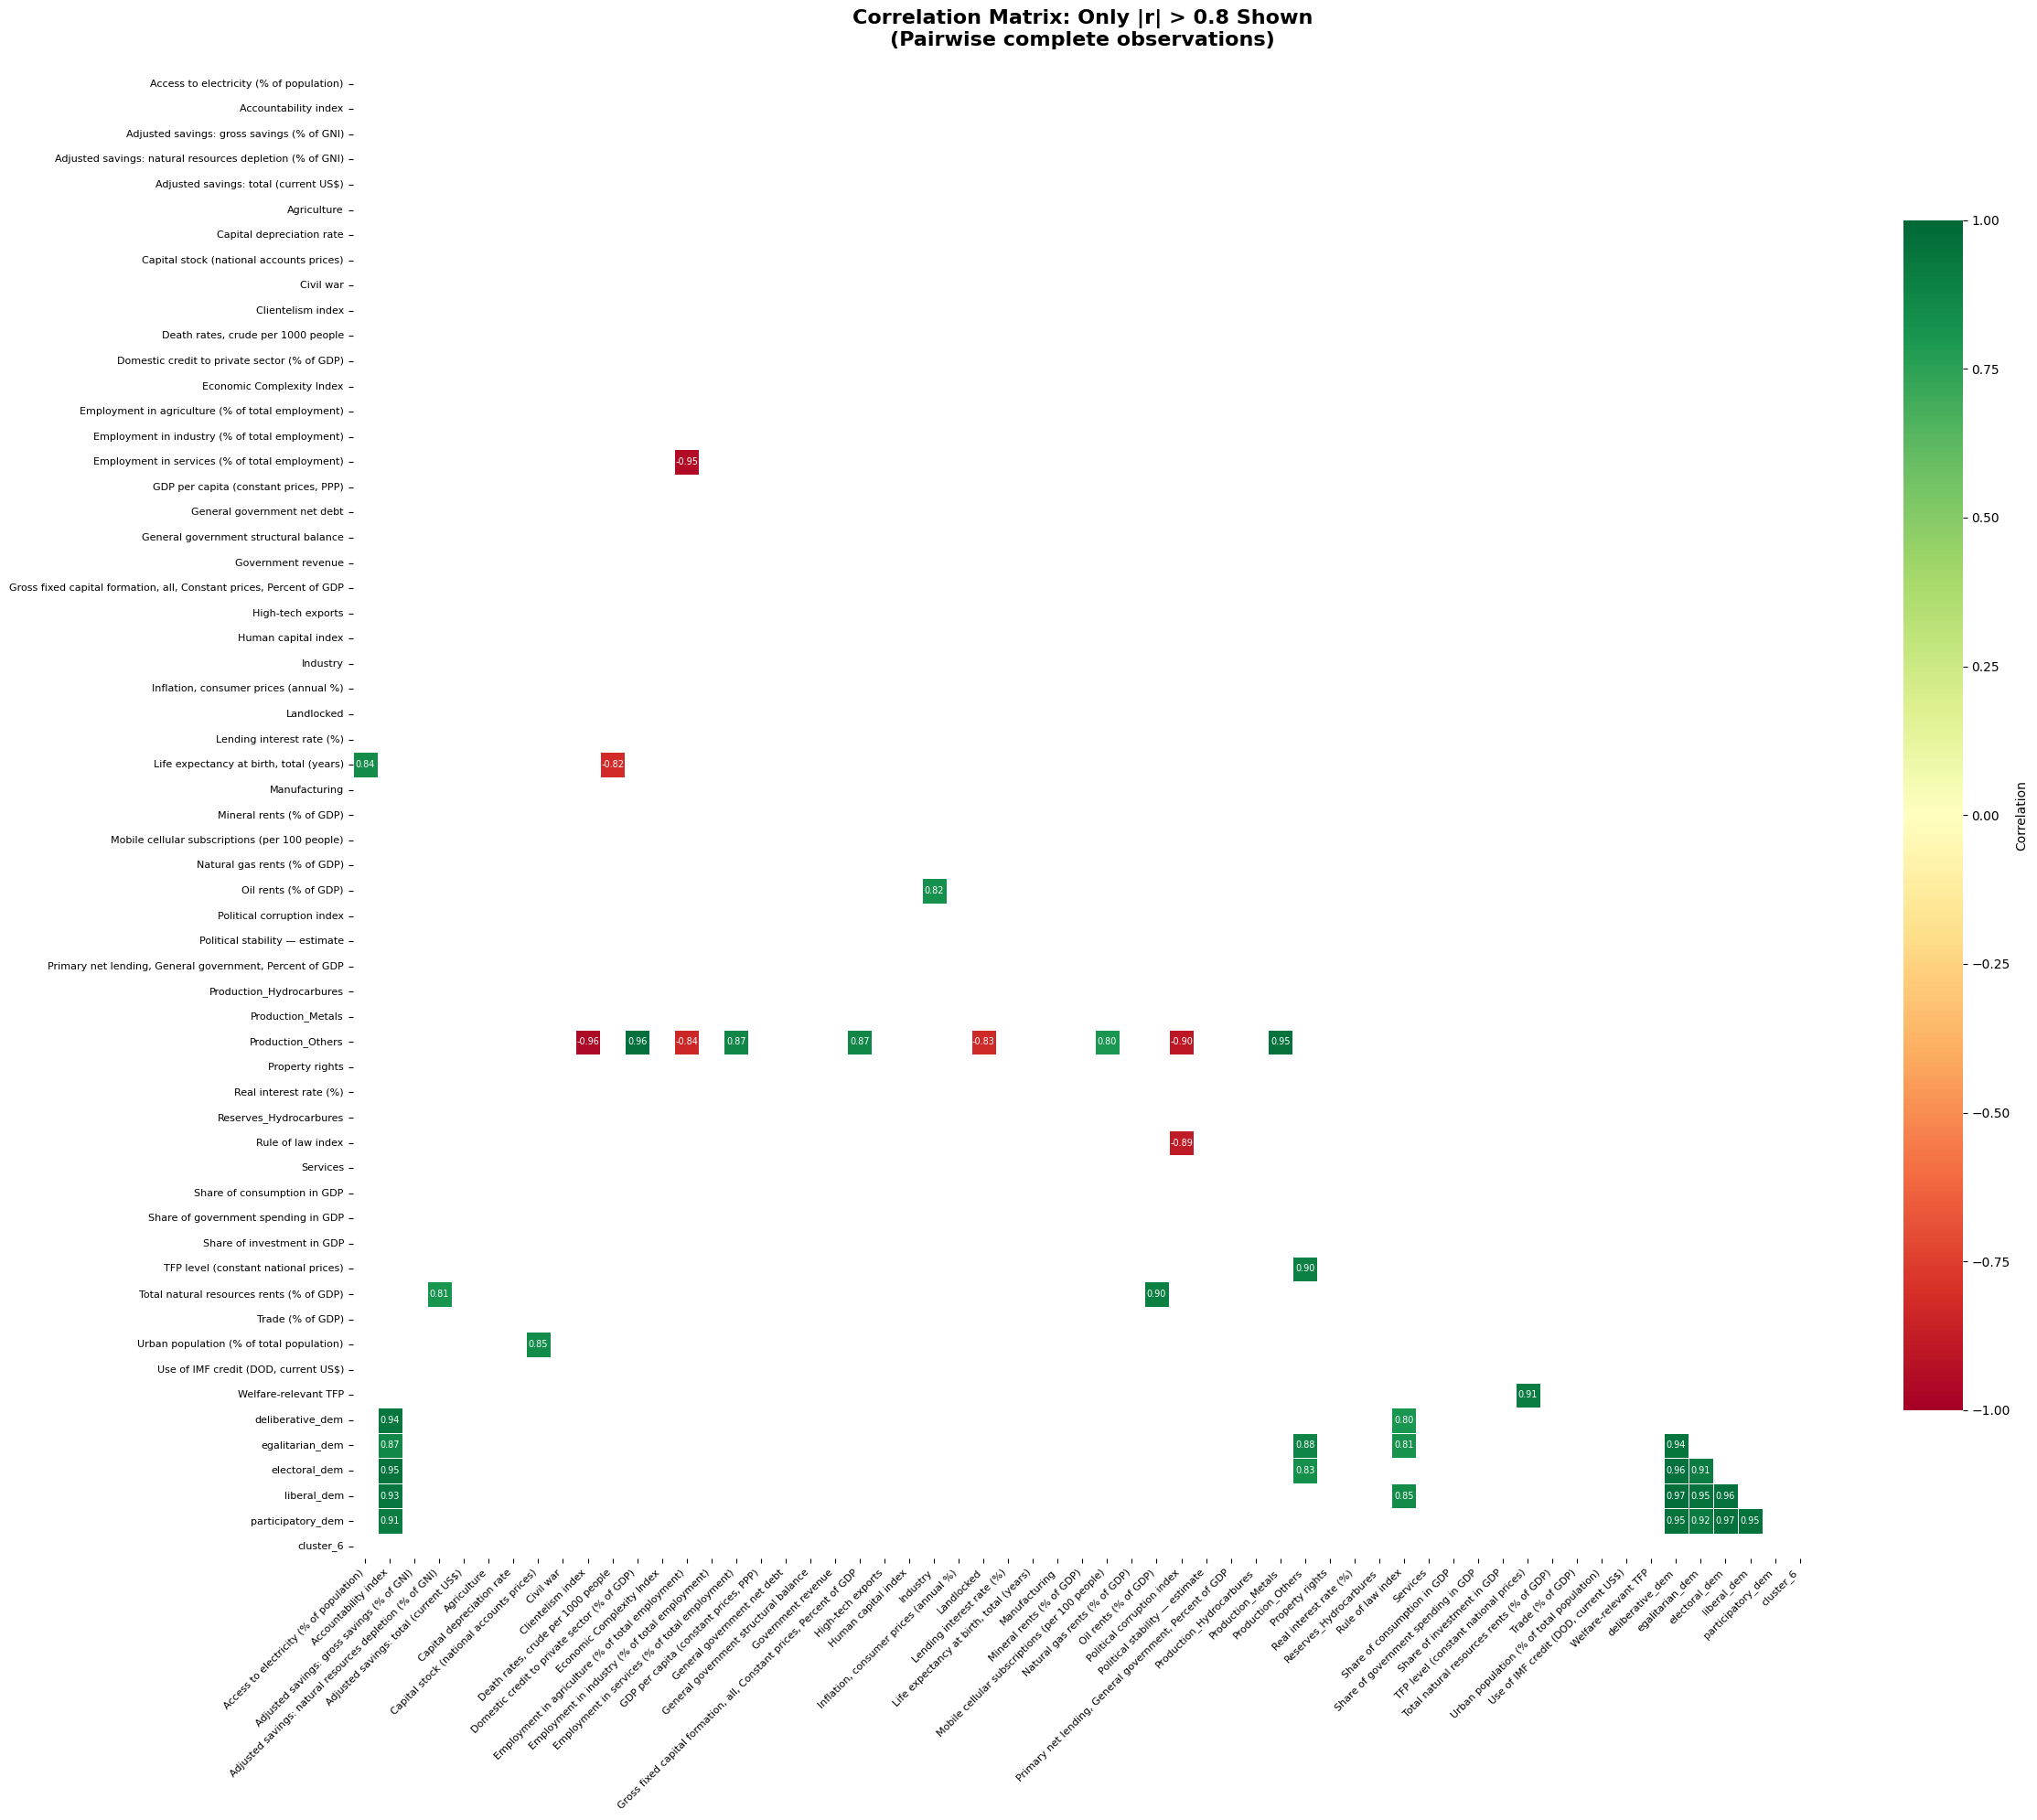


HIGH CORRELATION PAIRS (|r| > 0.8)
                                                         Variable 1                                     Variable 2  Correlation  N (pairwise)
                                                   deliberative_dem                                    liberal_dem        0.974          2343
                                                      electoral_dem                              participatory_dem        0.966          2350
                                                  Clientelism index                              Production_Others       -0.963            18
                       Domestic credit to private sector (% of GDP)                              Production_Others        0.963            18
                                                      electoral_dem                                    liberal_dem        0.958          2343
                                                   deliberative_dem                                  electoral_d

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Get all numeric indicator columns (exclude identifiers)
exclude_cols = ['Country Code', 'Country Name', 'Year']
indicator_cols = [c for c in cmaster.columns if c not in exclude_cols]

# Calculate correlation matrix using pairwise complete observations
corr_matrix = cmaster[indicator_cols].corr(method='pearson')

# ============================================================
# PLOT 1: Full Correlation Matrix with Custom Color Coding
# ============================================================
fig1, ax1 = plt.subplots(figsize=(24, 20))

# Create custom colormap: 
# Below 50% (0.5): light colors
# 50-80%: medium intensity
# Above 80%: strong intensity
# Using diverging colormap for positive/negative correlations

# Custom discrete boundaries
bounds = [-1, -0.8, -0.5, 0.5, 0.8, 1]
colors = ['#d73027', '#fc8d59', '#ffffbf', '#91cf60', '#1a9850']
cmap = LinearSegmentedColormap.from_list('custom', list(zip(
    [0, 0.1, 0.25, 0.75, 0.9, 1],
    ['#d73027', '#fc8d59', '#ffffbf', '#ffffbf', '#91cf60', '#1a9850']
)))

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, cmap='RdYlGn', center=0,
            annot=False, fmt='.2f',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Correlation', 'shrink': 0.8},
            vmin=-1, vmax=1, ax=ax1)

ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax1.set_yticklabels(ax1.get_yticklabels(), fontsize=8)
ax1.set_title('Correlation Matrix: All Indicators\n(Pairwise complete observations)', 
              fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# ============================================================
# PLOT 2: High Correlations Only (|r| > 0.5)
# ============================================================
fig2, ax2 = plt.subplots(figsize=(24, 20))

# Mask correlations below 0.5 absolute value
corr_masked = corr_matrix.copy()
corr_masked[(abs(corr_masked) < 0.5)] = np.nan

# Also mask upper triangle and diagonal
mask_upper = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_masked, mask=mask_upper, cmap='RdYlGn', center=0,
            annot=True, fmt='.2f', annot_kws={'size': 6},
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Correlation', 'shrink': 0.8},
            vmin=-1, vmax=1, ax=ax2)

ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax2.set_yticklabels(ax2.get_yticklabels(), fontsize=8)
ax2.set_title('Correlation Matrix: Only |r| > 0.5 Shown\n(Pairwise complete observations)', 
              fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# ============================================================
# PLOT 3: Very High Correlations Only (|r| > 0.8)
# ============================================================
fig3, ax3 = plt.subplots(figsize=(24, 20))

# Mask correlations below 0.8 absolute value
corr_masked_80 = corr_matrix.copy()
corr_masked_80[(abs(corr_masked_80) < 0.8)] = np.nan

sns.heatmap(corr_masked_80, mask=mask_upper, cmap='RdYlGn', center=0,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Correlation', 'shrink': 0.8},
            vmin=-1, vmax=1, ax=ax3)

ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax3.set_yticklabels(ax3.get_yticklabels(), fontsize=8)
ax3.set_title('Correlation Matrix: Only |r| > 0.8 Shown\n(Pairwise complete observations)', 
              fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('correlation_matrix_above80.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# TABLE: List of High Correlations
# ============================================================
print("\n" + "=" * 90)
print("HIGH CORRELATION PAIRS (|r| > 0.8)")
print("=" * 90)

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.8:
            var1 = corr_matrix.columns[i]
            var2 = corr_matrix.columns[j]
            # Count pairwise complete observations
            n_obs = cmaster[[var1, var2]].dropna().shape[0]
            high_corr_pairs.append({
                'Variable 1': var1,
                'Variable 2': var2,
                'Correlation': round(corr_val, 3),
                'N (pairwise)': n_obs
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=abs, ascending=False)
print(high_corr_df.to_string(index=False))

print("\n" + "=" * 90)
print("MODERATE-HIGH CORRELATION PAIRS (0.5 < |r| <= 0.8)")
print("=" * 90)

moderate_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if 0.5 < abs(corr_val) <= 0.8:
            var1 = corr_matrix.columns[i]
            var2 = corr_matrix.columns[j]
            n_obs = cmaster[[var1, var2]].dropna().shape[0]
            moderate_corr_pairs.append({
                'Variable 1': var1,
                'Variable 2': var2,
                'Correlation': round(corr_val, 3),
                'N (pairwise)': n_obs
            })

moderate_corr_df = pd.DataFrame(moderate_corr_pairs).sort_values('Correlation', key=abs, ascending=False)
print(moderate_corr_df.to_string(index=False))

# ============================================================
# SUMMARY STATISTICS
# ============================================================
print("\n" + "=" * 90)
print("CORRELATION SUMMARY")
print("=" * 90)

# Flatten upper triangle (excluding diagonal)
upper_tri_vals = corr_matrix.where(~np.triu(np.ones_like(corr_matrix, dtype=bool))).stack()

print(f"\nTotal variable pairs: {len(upper_tri_vals)}")
print(f"Pairs with |r| > 0.8: {len(high_corr_df)} ({len(high_corr_df)/len(upper_tri_vals)*100:.1f}%)")
print(f"Pairs with 0.5 < |r| <= 0.8: {len(moderate_corr_df)} ({len(moderate_corr_df)/len(upper_tri_vals)*100:.1f}%)")
print(f"Pairs with |r| <= 0.5: {len(upper_tri_vals) - len(high_corr_df) - len(moderate_corr_df)}")


In [12]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# Get all numeric indicator columns (exclude identifiers)
exclude_cols = ['Country Code', 'Country Name', 'Year']
indicator_cols = [c for c in cmaster.columns if c not in exclude_cols]

# Calculate correlation matrix using pairwise complete observations
corr_matrix = cmaster[indicator_cols].corr(method='pearson')

# Create a matrix for sample sizes (pairwise N)
n_matrix = pd.DataFrame(index=indicator_cols, columns=indicator_cols, dtype=float)
for i, var1 in enumerate(indicator_cols):
    for j, var2 in enumerate(indicator_cols):
        n_matrix.loc[var1, var2] = cmaster[[var1, var2]].dropna().shape[0]

# Mask correlations below 0.5 for display
corr_display = corr_matrix.copy()
corr_display[abs(corr_display) < 0.5] = np.nan

# Mask upper triangle (keep only lower triangle)
mask_upper = np.triu(np.ones_like(corr_display, dtype=bool), k=0)
corr_display = corr_display.mask(mask_upper)

# Create hover text matrix (lower triangle only)
hover_text = []
for i, var1 in enumerate(indicator_cols):
    row_text = []
    for j, var2 in enumerate(indicator_cols):
        corr_val = corr_matrix.iloc[i, j]
        n_val = int(n_matrix.iloc[i, j])
        
        # Only show hover info for lower triangle
        if i > j:
            if abs(corr_val) >= 0.5:
                strength = "Very Strong" if abs(corr_val) >= 0.8 else "Strong"
                direction = "Positive" if corr_val > 0 else "Negative"
                text = (
                    f"<b>Variable 1:</b> {var1}<br>"
                    f"<b>Variable 2:</b> {var2}<br>"
                    f"<b>Correlation:</b> {corr_val:.3f}<br>"
                    f"<b>Strength:</b> {strength} {direction}<br>"
                    f"<b>N (pairwise obs):</b> {n_val}"
                )
            else:
                text = (
                    f"<b>Variable 1:</b> {var1}<br>"
                    f"<b>Variable 2:</b> {var2}<br>"
                    f"<b>Correlation:</b> {corr_val:.3f}<br>"
                    f"<b>Strength:</b> Weak (|r| < 0.5)<br>"
                    f"<b>N (pairwise obs):</b> {n_val}"
                )
        else:
            text = ""  # Empty for upper triangle and diagonal
        row_text.append(text)
    hover_text.append(row_text)

# Create the interactive heatmap
fig = go.Figure(data=go.Heatmap(
    z=corr_display.values,
    x=indicator_cols,
    y=indicator_cols,
    hovertext=hover_text,
    hoverinfo='text',
    colorscale='RdYlGn',
    zmid=0,
    zmin=-1,
    zmax=1,
    colorbar=dict(
        title='Correlation',
        tickvals=[-1, -0.8, -0.5, 0, 0.5, 0.8, 1],
        ticktext=['-1.0', '-0.8', '-0.5', '0', '0.5', '0.8', '1.0']
    ),
    xgap=2,
    ygap=2
))

# Update layout
fig.update_layout(
    title=dict(
        text='Interactive Correlation Matrix (|r| > 0.5 shown)<br><sup>Hover over cells to see variable details and correlation strength</sup>',
        font=dict(size=16)
    ),
    width=1200,
    height=1100,
    xaxis=dict(
        tickangle=45,
        tickfont=dict(size=8),
        side='bottom',
        tickmode='array',
        tickvals=list(range(len(indicator_cols))),
        ticktext=indicator_cols
    ),
    yaxis=dict(
        tickfont=dict(size=8),
        autorange='reversed',
        tickmode='array',
        tickvals=list(range(len(indicator_cols))),
        ticktext=indicator_cols
    ),
    plot_bgcolor='white'
)



# Show plot
fig.show()

# Save as interactive HTML
fig.write_html('correlation_matrix_interactive.html')
print("\nInteractive correlation matrix saved as 'correlation_matrix_interactive.html'")
print("Open this file in a browser for full interactivity!")
print("\nFeatures:")
print("  - Hover over any cell to see full variable names and correlation details")
print("  - Cells with |r| < 0.5 shown as blank (but still hoverable)")
print("  - Cells with |r| > 0.8 have correlation values annotated")
print("  - Zoom, pan, and download options available in toolbar")


Interactive correlation matrix saved as 'correlation_matrix_interactive.html'
Open this file in a browser for full interactivity!

Features:
  - Hover over any cell to see full variable names and correlation details
  - Cells with |r| < 0.5 shown as blank (but still hoverable)
  - Cells with |r| > 0.8 have correlation values annotated
  - Zoom, pan, and download options available in toolbar
